# Seismic Modeling

In [1]:
from geod67lib.wavefield import *
from geod67lib.wavefield.damp import generate_damp_mask

from geod67lib import fd

import numpy as np
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt


2026-06-01 15:48:34.677966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 15:48:34.701186: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# shape = (301, 301)
shape = (170, 80)
# h = (10, 10)
h = (25, 25)

nbl = 40

# vp_data = 1.5 * np.ones(shape, dtype=np.float32)
# vp_data[:,shape[1]//2:] = 3

vp_data = np.fromfile('./data/marmo_vp_nx170nz80dx25dz25.bin', dtype=np.float32).reshape(shape)/1e3

vp_data = np.pad(vp_data, nbl, mode='edge')
# damp_mask = np.zeros_like(vp_data)
damp_mask = generate_damp_mask(vp_data, nbl)

vp = VelocityModel(vp_data, h[0], h[1])

In [3]:
vp_data.max()

np.float32(4.45)

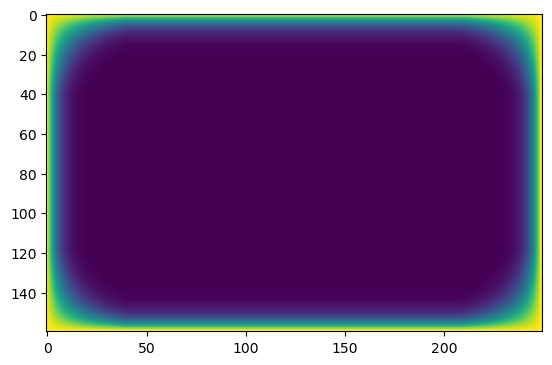

In [4]:
plt.imshow(damp_mask.T)

In [5]:
src_positions = np.array([[vp.shape[0]//2, nbl]], dtype=np.int32)

# nrec = (shape[0] - 2*nbl)//2
nrec = (vp.shape[0] - 2*nbl)

rec_positions = np.array([
    [xr, nbl] for xr in np.linspace(nbl, vp.shape[0] - nbl, dtype=np.int32, num=nrec)
], dtype=np.int32)

In [6]:
rec_positions

array([[ 40,  40],
       [ 41,  40],
       [ 42,  40],
       [ 43,  40],
       [ 44,  40],
       [ 45,  40],
       [ 46,  40],
       [ 47,  40],
       [ 48,  40],
       [ 49,  40],
       [ 50,  40],
       [ 51,  40],
       [ 52,  40],
       [ 53,  40],
       [ 54,  40],
       [ 55,  40],
       [ 56,  40],
       [ 57,  40],
       [ 58,  40],
       [ 59,  40],
       [ 60,  40],
       [ 61,  40],
       [ 62,  40],
       [ 63,  40],
       [ 64,  40],
       [ 65,  40],
       [ 66,  40],
       [ 67,  40],
       [ 68,  40],
       [ 69,  40],
       [ 70,  40],
       [ 71,  40],
       [ 72,  40],
       [ 73,  40],
       [ 74,  40],
       [ 75,  40],
       [ 76,  40],
       [ 77,  40],
       [ 78,  40],
       [ 79,  40],
       [ 80,  40],
       [ 81,  40],
       [ 82,  40],
       [ 83,  40],
       [ 84,  40],
       [ 85,  40],
       [ 86,  40],
       [ 87,  40],
       [ 88,  40],
       [ 89,  40],
       [ 90,  40],
       [ 91,  40],
       [ 92,

In [7]:
dt = 2.0  # ms
tn = 3000 # ms
fpeak = 5 * 1e-3

src_wavelet = np.array([ricker(fpeak, dt, int(tn//dt))])

In [8]:
ap = AquisitionParameters(src_positions, rec_positions, dt, tn, src_wavelet)

In [9]:
op = ForwardOperator(ap, damp_mask)

In [10]:
u_history = op.forward(vp, True)

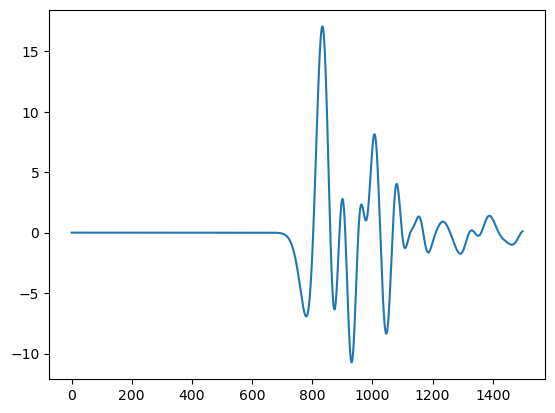

In [11]:
plt.plot(ap.rec_data[0])

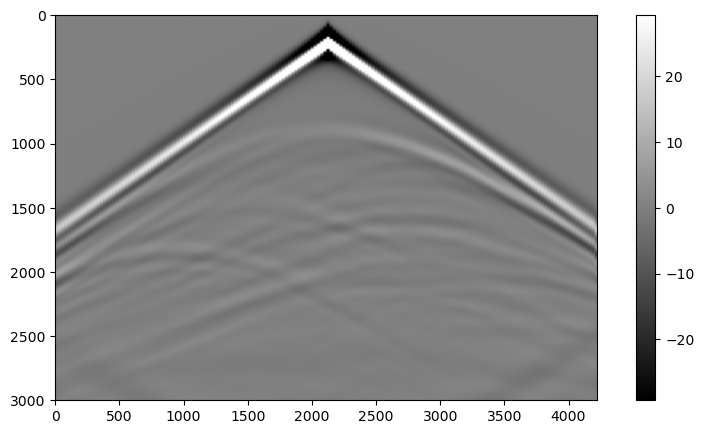

In [12]:
vmax = np.abs(ap.rec_data).max()/10

plt.figure(figsize=(10,5))
plt.imshow(ap.rec_data.T, extent=[
    0, (vp.width - 2*nbl*vp.hx), tn, 0
], cmap='grey', vmax=vmax, vmin=-vmax)
plt.colorbar()

In [13]:
len(u_history)

1500

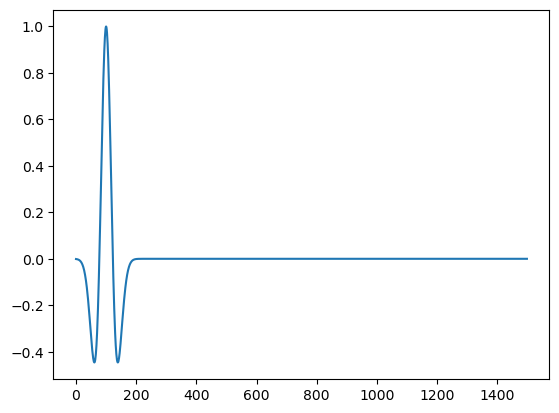

In [14]:
plt.plot(ricker(fpeak, dt, tn//dt))

In [15]:
ap.nt

1500

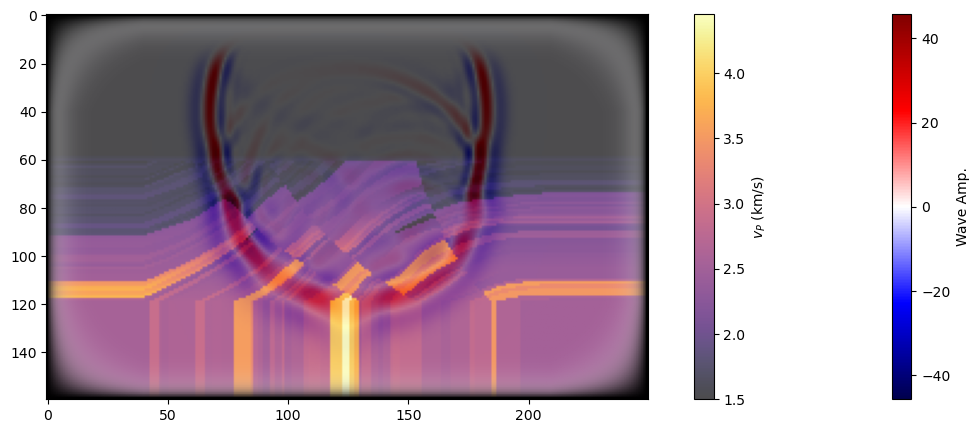

In [16]:
idx = 600
vmax = np.abs(u_history[idx]).max()
plt.figure(figsize=(15,5))
plt.imshow(u_history[idx].T - np.median(u_history[idx]), cmap='seismic', vmax=vmax , vmin=-vmax)
# plt.imshow(u_history[idx].T - u_history[idx-1].T, cmap='seismic', vmax=vmax , vmin=-vmax)
plt.colorbar(label='Wave Amp.')
plt.imshow(vp.data.T, cmap='inferno', alpha=0.7, vmin = vp.data.min(), vmax=vp.data.max())
plt.colorbar(label='$v_P$ (km/s)')
plt.imshow(1-damp_mask.T, cmap='grey', alpha=damp_mask.T)

# plt.scatter
# plt.colorbar(label='$v_P$ (km/s)')

## Migration (1 Src)

In [17]:
apT = ap.adjoint_parameters()

In [18]:
opT = ForwardOperator(apT, damp_mask)

In [19]:
v_history = opT.forward(vp, True)

In [20]:
len(v_history)

1500

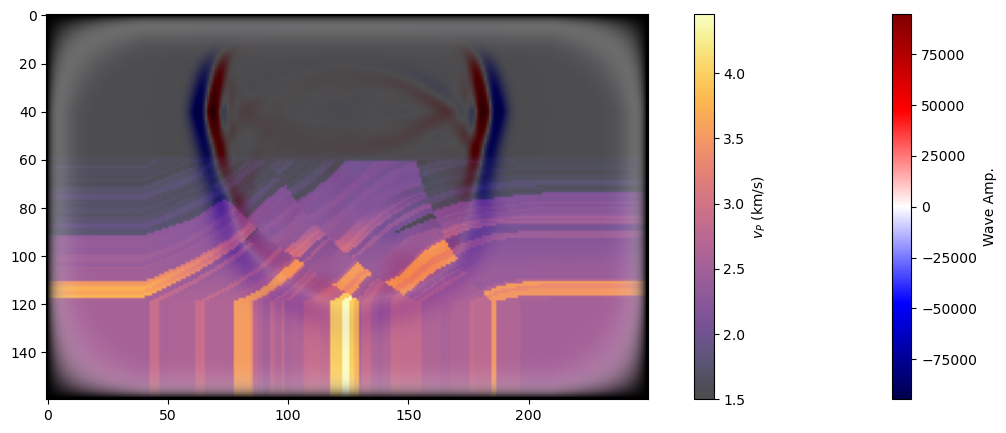

In [21]:
idx = 600
vmax = np.abs(v_history[idx]).max()
plt.figure(figsize=(15,5))
plt.imshow(v_history[idx].T - np.median(v_history[idx]), cmap='seismic', vmax=vmax , vmin=-vmax)
# plt.imshow(u_history[idx].T - u_history[idx-1].T, cmap='seismic', vmax=vmax , vmin=-vmax)
plt.colorbar(label='Wave Amp.')
plt.imshow(vp.data.T, cmap='inferno', alpha=0.7, vmin = vp.data.min(), vmax=vp.data.max())
plt.colorbar(label='$v_P$ (km/s)')
plt.imshow(1-damp_mask.T, cmap='grey', alpha=damp_mask.T)

# plt.scatter
# plt.colorbar(label='$v_P$ (km/s)')

In [22]:
zeta = np.zeros_like(u_history[0]) 
illum = np.zeros_like(u_history[0])

for ti in range(ap.nt):
    ui = u_history[ti]
    vi = v_history[-(ti+1)]

    illum += ui**2
    zeta += ui * vi

## Migration

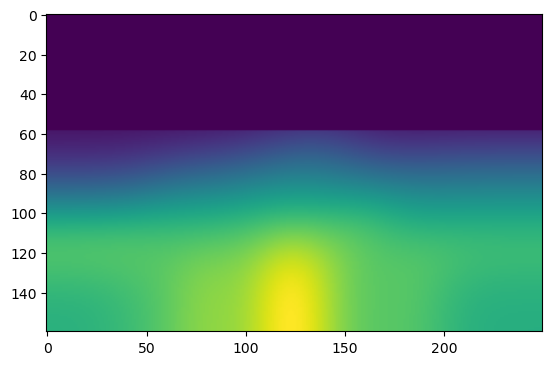

In [33]:
sigma = 16
vp0_data = gaussian_filter(vp.data, sigma)
vp0_data[vp_data <= 1.51] = vp_data[vp_data <= 1.51]
vp0 = VelocityModel(vp0_data, vp.hx, vp.hz)
plt.imshow(vp0_data.T)

In [73]:
sx = np.linspace(nbl, vp.shape[0] - nbl, num=10, dtype=np.float32)
sx

array([ 40.      ,  58.88889 ,  77.77778 ,  96.666664, 115.55556 ,
       134.44444 , 153.33333 , 172.22223 , 191.11111 , 210.      ],
      dtype=float32)

In [74]:
dobs = []
for sxi in sx:
    ap.reset()
    ap.src_positions[0][0] = sxi

    op.forward(vp)
    dobs.append(ap.rec_data)

dobs = np.array(dobs)

In [75]:
dobs.shape


(10, 170, 1500)

In [79]:
def compute_image(i):
    ap.reset()
    ap.src_positions[0][0] = sx[i]

    u_history = op.forward(vp0, True)

    res = ap.rec_data - dobs[i]
    res = np.flip(res, axis=0)
    apT.reset()
    apT.src_wavelet = res

    v_history = opT.forward(vp0, True)
    v_history = list(reversed(v_history))
    
    zeta = np.zeros_like(u_history[0]) 
    illum = np.zeros_like(u_history[0])
    
    for ti in range(ap.nt):
        ui = u_history[ti]
        # vi = v_history[-(ti+1)]
        vi = v_history[ti]
    
        illum += ui**2
        zeta += ui * vi
        zeta[vp.data <=1.51] = 0

    return zeta, illum
    
    

In [82]:
zeta_full = np.zeros_like(vp0.data)
illum_full = np.zeros_like(vp0.data)
for i in range(len(sx)):
    print(i+1, '/', len(sx))
    zi, ii = compute_image(i)
    zeta_full += zi
    illum_full += ii

zeta_full /= (illum + 1e-9)

1 / 10
2 / 10
3 / 10
4 / 10
5 / 10
6 / 10
7 / 10
8 / 10
9 / 10
10 / 10


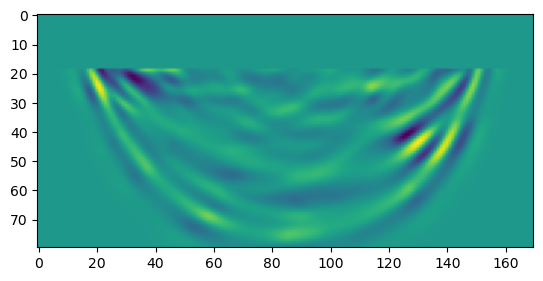

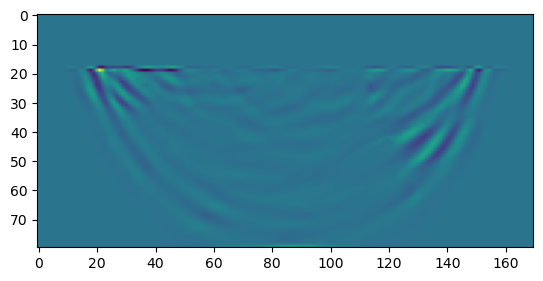

In [83]:
plt.imshow(zeta_full.T[nbl:-nbl, nbl:-nbl])
plt.figure()
plt.imshow(fd.lap2D(zeta_full.T[nbl:-nbl, nbl:-nbl], vp.hx, vp.hz))